### Does Synthetic Data Augmentation Improve MVO?

Testing resilience of synthetic data from the improved diffusion run (**step 450**, DDPM, temperature **0.7473**). Synthetic paths are built from `generated_data.csv` in `test_results/450_discrete_DDPM_0.7473/` and loaded from the `notebook_data5/` subfolder there. Evaluation uses the **10 assets** from `benchmark_data_log_ret_10.csv` (2013–2022). 

### What are we trying to answer:

We want to see if when a portfolio is subjected to market stress conditions, whether it performs better (is the portfolio more resillient?) if the MVO is augmented with synthetic returns compared to training only on historical data. 

It's worth mentioning that whilst we are testing if it can be used to develop a more resillient portfolio. Based on talking with industry professionals we decided against using to attempt to find alpha as the alpha would come from the GANs themselves not the market thus likely giving false indicators. 

The metrics I will be mostly using to determine performance is sharpe, calmar, max drawdown and cvar. However calmar will be our main focus during stress testing because it focuses on loss which is important when determining fund performances because funds are often defined in stress periods by how much they lose or can stand to lose. 

### imports

In [1]:
from __future__ import annotations
from portfolio_core import (
    TRADING_DAYS, 
    classify_regime,
    pct_returns, 
    sharpe_ratio,
    mean_var_weights,
    collapse_weights,
    mix_train_matrix,
    calmar_ratio,
    summarize_portfolio
)

from stress_test_final import (
    shock_test
)

from portfolio_eval_final import (
    portfolio_experiment,
    plot_metric_curve
)
from data_utils import load_real_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
random_seed = 42
np.random.seed(random_seed)

### Useful info about the dataset(s):

The files from the folder contains synthetic log returns. The asset dates span from 01.01.2013 to 31.08.22 (should be 2522 rows) that I have labeled by calendar date. FYI 2013.01.01 was not a trading date so i start on the second. 

In [3]:
from pathlib import Path
import sys

# Project root = Synthetic-data-tests/ when this notebook lives in evaluation/
EVAL_DIR = Path(".").resolve()
PROJECT_ROOT = EVAL_DIR.parent
if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))

# Prebuilt synth used by the notebooks
TEST_RUN_DIR = (PROJECT_ROOT / "results" / "450_discrete_DDPM_0.7473").resolve()
GENERATED_CSV = TEST_RUN_DIR / "generated_data.csv"
SYNTH_DIR = TEST_RUN_DIR / "notebook_data5"

ASSET_COLS = ['A001', 'A004', 'A006', 'A008', 'A009',
              'A011', 'A012', 'A013', 'A014', 'A015']

print("Project root:", PROJECT_ROOT)
print("Test run:", TEST_RUN_DIR)
print("Generated CSV exists:", GENERATED_CSV.exists())
print("Notebook synth dir:", SYNTH_DIR)

df_real = load_real_data(str(EVAL_DIR / "data" / "benchmark" / "benchmark_data.csv"), benchmark=True)
df_real = df_real[ASSET_COLS]
df_real = df_real.loc["2013-01-01":"2022-08-31"]

print(df_real.shape)   # we expect 2522 rows x 10 assets
print("Date range:", df_real.index[0].date(), "to", df_real.index[-1].date())
df_real.head()


Project root: /Users/mohanyang/Desktop/ruya/Synthetic-data-tests
Test run: /Users/mohanyang/Desktop/ruya/Synthetic-data-tests/results/450_discrete_DDPM_0.7473
Generated CSV exists: True
Notebook synth dir: /Users/mohanyang/Desktop/ruya/Synthetic-data-tests/results/450_discrete_DDPM_0.7473/notebook_data5
(2522, 10)
Date range: 2013-01-01 to 2022-08-31


,A001,A004,A006,A008,A009,A011,A012,A013,A014,A015
timestamp,,,,,,,,,,
2013-01-01,5418.89,1844.39,247.279,1472.56,672.101,6794.71,3902.37,4170.41,421.693,799.189
2013-01-02,5557.60,1840.40,247.269,1478.76,674.226,6955.22,4013.04,4241.98,430.652,809.127
2013-01-03,5545.99,1836.93,247.271,1481.97,675.823,6955.92,4009.33,4233.00,432.464,809.216
2013-01-04,5572.98,1836.38,247.270,1483.09,674.651,7010.45,4039.46,4245.94,430.556,812.771
2013-01-07,5555.61,1837.68,247.311,1485.47,673.030,6983.16,4024.06,4241.20,429.724,814.803


In [4]:
import subprocess
import sys

def ensure_notebook_synth_data():
    """Build notebook_data5/ from generated_data.csv if missing."""
    marker = SYNTH_DIR / "metadata.json"
    if marker.exists():
        return
    if not GENERATED_CSV.exists():
        raise FileNotFoundError(f"Missing generated data: {GENERATED_CSV}")
    script = PROJECT_ROOT / "train" / "scripts" / "convert_diffusion_generated_to_data5.py"
    benchmark_csv = EVAL_DIR / "data" / "benchmark" / "benchmark_data.csv"
    cmd = [
        sys.executable, str(script),
        "--generated-csv", str(GENERATED_CSV),
        "--benchmark-csv", str(benchmark_csv),
        "--output-dir", str(SYNTH_DIR),
    ]
    print("Converting generated_data.csv -> notebook_data5 ...")
    subprocess.run(cmd, check=True, cwd=str(PROJECT_ROOT / "train"))

def load_synth_pool_data5(path):
    # Synthetic files are log-returns, date-indexed.
    # mix_train_matrix expects simple returns.
    df = pd.read_csv(path, index_col=0).astype(float)
    df.index = pd.to_datetime(df.index)
    return np.expm1(df)

ensure_notebook_synth_data()

synth_pools = {
    asset: load_synth_pool_data5(
        SYNTH_DIR / f"{asset}_synthetic_log_returns_2013_2022_20seq.csv"
    )
    for asset in ASSET_COLS
}

for asset, pool in synth_pools.items():
    print(f"{asset}: {pool.shape[0]} rows x {pool.shape[1]} series")

A001: 2521 rows x 20 series
A004: 2521 rows x 20 series
A006: 2521 rows x 20 series
A008: 2521 rows x 20 series
A009: 2521 rows x 20 series
A011: 2521 rows x 20 series
A012: 2521 rows x 20 series
A013: 2521 rows x 20 series
A014: 2521 rows x 20 series
A015: 2521 rows x 20 series


Good to know: Each synethic dataset for each asset contains 20 columns of synthetic data that can be used to augment the initial historical column data. Each column containing our sequences is 2521 rows stores by indexing on calendar dates. 

When augmenting the real data we draw a select number of synthetic columns from 1–20 at random. These are added to the return matrix so we get **10 + 10×n** columns as our augmented matrix. The optimizer runs mean-variance optimization on that expanded matrix. After solving, we collapse the synthetic column weights back into each real asset, so the final portfolio is still a standard 10-asset portfolio. 

### First experiment: Rolling window, checking whether augmentation will help more in a crisis? 

To test this we use the method "classify_regime" to mark windows as either calm or crisis windows based on historical drawdowns and crashes within my timeframe(2013-2022)

A good result would see increased sharpe with augmentation of synthetic data during crisis periods which with this test is more important than looking at the calm periods. 

In [5]:
LOOKBACK = 252
INVEST   = 60 
STEP     = 21
MIX_GRID = (0, 1, 2, 5, 10, 15, 20)

real_rets   = pct_returns(df_real)
all_results = []

for start_idx in range(0, len(real_rets) - LOOKBACK - INVEST, STEP):
    test_start_idx  = start_idx + LOOKBACK
    test_end_idx    = test_start_idx + INVEST
    test_start_date = real_rets.index[test_start_idx]
    test_end_date   = real_rets.index[test_end_idx - 1]

    regime     = classify_regime(test_start_date, test_end_date)
    spy_test   = real_rets['A001'].iloc[test_start_idx:test_end_idx].values
    spy_sharpe = sharpe_ratio(spy_test)
    spy_calmar = calmar_ratio(spy_test)
    

    window_prices = df_real.iloc[start_idx: test_end_idx + 1]
    window_result = portfolio_experiment(
        real_prices=window_prices, synth_pools=synth_pools,
        asset_cols=ASSET_COLS, mix_grid=MIX_GRID,
        lookback_window=LOOKBACK, investment_window=INVEST, seed=42,
    )
    window_result['regime']     = regime
    window_result['test_start'] = test_start_date
    window_result['spy_sharpe'] = spy_sharpe
    window_result['spy_calmar'] = spy_calmar
    all_results.append(window_result)

results = pd.concat(all_results, ignore_index=True)
print(results.shape)
results.head(10)


(742, 15)


,bucket,sharpe,calmar,max_drawdown,VaR_5%,CVaR_5%,ann_mu,ann_sd,n_obs,n_synth_series,max_weight_used,regime,test_start,spy_sharpe,spy_calmar
0,ALL,1.342558,2.861754,-0.073990,-0.014071,-0.023505,0.211742,0.157715,60,0,1.000000,calm,2013-12-20,0.985410,1.967802
1,ALL,-0.820177,-1.133240,-0.078417,-0.013734,-0.016794,-0.088865,0.108349,60,1,0.756601,calm,2013-12-20,0.985410,1.967802
2,ALL,-0.820177,-1.133241,-0.078417,-0.013734,-0.016794,-0.088865,0.108349,60,2,0.756602,calm,2013-12-20,0.985410,1.967802
3,ALL,1.708972,3.873261,-0.056127,-0.012138,-0.021528,0.217396,0.127209,60,5,0.940791,calm,2013-12-20,0.985410,1.967802
4,ALL,1.585791,3.482907,-0.061874,-0.012177,-0.022159,0.215503,0.135896,60,10,0.625768,calm,2013-12-20,0.985410,1.967802
5,ALL,1.253775,2.575105,-0.058761,-0.010378,-0.019395,0.151316,0.120688,60,15,0.588435,calm,2013-12-20,0.985410,1.967802
6,ALL,1.342558,2.861754,-0.073990,-0.014071,-0.023505,0.211742,0.157715,60,20,1.000000,calm,2013-12-20,0.985410,1.967802
7,ALL,-0.966597,-2.282113,-0.078734,-0.023488,-0.028003,-0.179681,0.185890,60,0,1.000000,calm,2014-01-20,-0.176497,-0.410893
8,ALL,1.401396,2.654500,-0.061995,-0.012918,-0.016394,0.164565,0.117429,60,1,0.883662,calm,2014-01-20,-0.176497,-0.410893
9,ALL,1.401483,2.654712,-0.061994,-0.012917,-0.016394,0.164577,0.117431,60,2,0.883693,calm,2014-01-20,-0.176497,-0.410893


In [6]:
results.groupby(["regime", "n_synth_series"])[["sharpe", "calmar", "ann_mu", "ann_sd"]].mean()


sharpe    calmar    ann_mu    ann_sd
regime n_synth_series                                        
calm   0               0.845456  3.287055  0.076420  0.136584
       1               1.009418  3.710579  0.119101  0.140100
       2               0.958162  3.760927  0.134938  0.148501
       5               1.104577  3.843847  0.145059  0.139185
       10              1.077810  3.851664  0.150701  0.142610
       15              1.117418  4.003005  0.150943  0.137597
       20              1.335854  5.000431  0.164124  0.140001
crisis 0              -0.004901  1.653543 -0.151746  0.221888
       1              -0.264637  0.387405 -0.100143  0.275644
       2              -0.388978 -0.031333 -0.107454  0.284521
       5              -0.132259  0.526943 -0.069252  0.274019
       10             -0.164662  0.281508 -0.065780  0.289243
       15             -0.139397  0.389348 -0.063248  0.287420
       20             -0.300527  0.022768 -0.084411  0.293245

In [7]:
results.groupby(["regime", "n_synth_series"])[["sharpe", "calmar", "ann_mu", "ann_sd"]].median()


sharpe    calmar    ann_mu    ann_sd
regime n_synth_series                                        
calm   0               0.914214  2.350108  0.096324  0.135982
       1               1.142496  2.659865  0.140639  0.134406
       2               0.966571  2.325408  0.118876  0.138646
       5               0.988558  2.777032  0.116067  0.134374
       10              0.804360  1.910556  0.092957  0.134739
       15              1.034278  2.476098  0.118434  0.127523
       20              1.355092  3.666687  0.147970  0.140868
crisis 0              -0.393623 -0.721361 -0.102439  0.195093
       1              -0.675558 -1.174335 -0.173971  0.256300
       2              -0.878230 -1.468005 -0.159935  0.236485
       5              -0.566609 -1.001968 -0.106506  0.227559
       10             -0.703321 -1.167315 -0.142060  0.237444
       15             -0.574087 -1.132635 -0.128447  0.236390
       20             -0.698841 -1.172566 -0.124470  0.256529

### Plots showing the calmar and sharpe results as an average (median for calmar) over the rolling windows

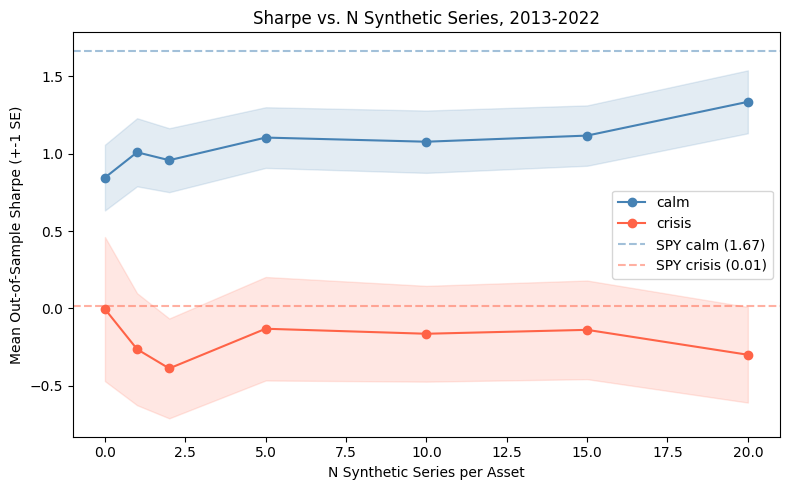

In [8]:
plot_metric_curve(results, metric="sharpe", estimator="mean", spy_col="spy_sharpe", title="Sharpe vs. N Synthetic Series, 2013-2022")
plt.tight_layout()
plt.show()


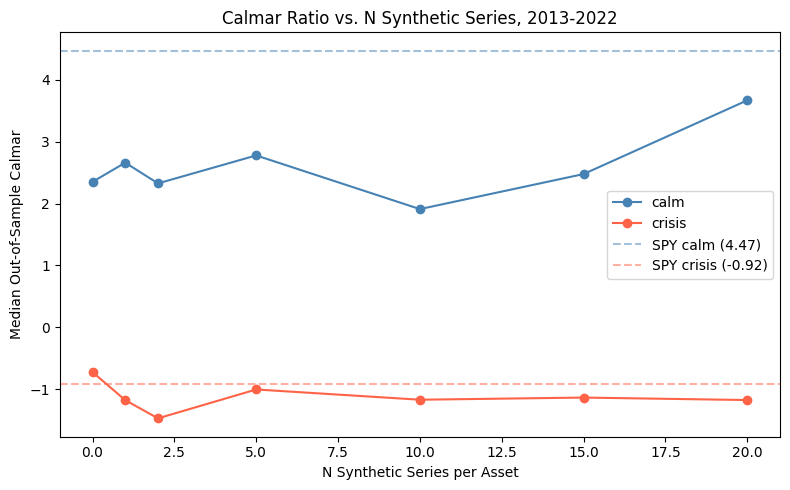

In [9]:
plot_metric_curve(results, metric="calmar", estimator ="median",spy_col="spy_calmar", title="Calmar Ratio vs. N Synthetic Series, 2013-2022")
plt.tight_layout()
plt.show()

### Crisis-focused paired deltas vs n_synth=0

For each rolling window, compare augmented portfolios to the same-window `n=0` baseline. Stress-ranked synthetic columns are now preferred in `mix_train_matrix` / `portfolio_experiment`.


In [10]:
keys = ["test_start", "regime"]
base = results.loc[results["n_synth_series"] == 0, keys + ["sharpe", "calmar", "max_drawdown"]].rename(
    columns={"sharpe": "sharpe_n0", "calmar": "calmar_n0", "max_drawdown": "max_drawdown_n0"}
)
aug = results.loc[results["n_synth_series"] > 0].merge(base, on=keys, how="inner")
aug["delta_sharpe"] = aug["sharpe"] - aug["sharpe_n0"]
aug["delta_calmar"] = aug["calmar"] - aug["calmar_n0"]
aug["delta_max_drawdown"] = aug["max_drawdown"] - aug["max_drawdown_n0"]

summary = (
    aug.groupby(["regime", "n_synth_series"])
    .agg(
        n_windows=("delta_sharpe", "size"),
        delta_sharpe_mean=("delta_sharpe", "mean"),
        delta_sharpe_winrate=("delta_sharpe", lambda s: float((s > 0).mean())),
        delta_calmar_mean=("delta_calmar", "mean"),
        delta_calmar_winrate=("delta_calmar", lambda s: float((s > 0).mean())),
        delta_max_dd_mean=("delta_max_drawdown", "mean"),
    )
    .round(4)
)
display(summary)

if "max_weight_used" in results.columns:
    print("\nMean max |weight| by n_synth (corner-solution check):")
    display(results.groupby(["regime", "n_synth_series"])["max_weight_used"].mean().round(4))


n_windows  delta_sharpe_mean  delta_sharpe_winrate  \
regime n_synth_series                                                       
calm   1                      84             0.1640                0.4881   
       2                      84             0.1127                0.4643   
       5                      84             0.2591                0.6310   
       10                     84             0.2324                0.5833   
       15                     84             0.2720                0.6310   
       20                     84             0.4904                0.6310   
crisis 1                      22            -0.2597                0.4545   
       2                      22            -0.3841                0.2727   
       5                      22            -0.1274                0.3636   
       10                     22            -0.1598                0.4545   
       15                     22            -0.1345                0.4545   
       20                     22            -0.2956                0.3182   

                       delta_calmar_mean  delta_calmar_winrate  \
regime n_synth_series                                            
calm   1                          0.4235                0.4881   
       2                          0.4739                0.5000   
       5                          0.5568                0.6310   
       10                         0.5646                0.5833   
       15                         0.7159                0.6190   
       20                         1.7134                0.6310   
crisis 1                         -1.2661                0.4091   
       2                         -1.6849                0.2273   
       5                         -1.1266                0.3182   
       10                        -1.3720                0.4091   
       15                        -1.2642                0.4091   
       20                        -1.6308                0.2727   

                       delta_max_dd_mean  
regime n_synth_series                     
calm   1                          0.0001  
       2                         -0.0020  
       5                          0.0036  
       10                         0.0029  
       15                         0.0063  
       20                         0.0053  
crisis 1                         -0.0224  
       2                         -0.0212  
       5                         -0.0168  
       10                        -0.0225  
       15                        -0.0219  
       20                        -0.0265


Mean max |weight| by n_synth (corner-solution check):


regime  n_synth_series
calm    0                 0.9634
        1                 0.9396
        2                 0.9456
        5                 0.8615
        10                0.9046
        15                0.8809
        20                0.8569
crisis  0                 0.9180
        1                 0.9192
        2                 0.8598
        5                 0.8947
        10                0.7953
        15                0.8232
        20                0.8067
Name: max_weight_used, dtype: float64

### Second experiment: Shock Testing - Testing our main stress tests

What are we trying to test: For each shock scenario written does augmentation with synthetic data help produce better result metrics looking at stress metrics: drawdown and cvar

Portfolio weights are trained on unshocked training data, then we apply the shock to the out-of-sample test returns. This allows us to see whether the weights that are found with the augmented COV matrix is more resillient to stressful periods in the market such as when simulating the 2008 market crash. Or if it's only useful in mimicking training distribution. 

In [11]:
SHOCK_LOOKBACK = 252    
SHOCK_INVEST   = 300

CUSTOM_SCENARIOS = [
    ("BASE",{"shock_type": "VOL_SCALE","vol_scale": 1.0}),
    ("VOL_SCALE_1.8x",{"shock_type": "VOL_SCALE","vol_scale": 1.8}),
    ("NEG_SHOCK_-10%",{"shock_type": "NEG_RETURN_SHOCK", "shock_size": 0.10}),
    ("CORR_INFLATE_1.3",{"shock_type": "CORR_INFLATE","corr_inflate": 1.3}),
    ("WHIPSAW",{"shock_type":"WHIPSAW"}),
    ("SLOW_BLEED",{"shock_type":"SLOW_BLEED"}),
    ("CRASH_2008",{"shock_type":"crash_2008"}),
]
shock_results = dict()
for n in MIX_GRID:
    shock_result = shock_test(
    real_prices=df_real, synth_pools=synth_pools, asset_cols=ASSET_COLS,
    n_synth_series=n, lookback_window=SHOCK_LOOKBACK,
    investment_window=SHOCK_INVEST, scenarios=CUSTOM_SCENARIOS,
    )
    shock_results[n] = shock_result

aggregated_results = []
for n, shock_result in shock_results.items():
    agg = pd.concat(shock_result).groupby("bucket").median(numeric_only=True).reset_index()
    aggregated_results.append((n, agg))

metrics = ["sharpe", "calmar", "CVaR_5%", "max_drawdown"]
comp = aggregated_results[0][1][["bucket"]].copy()
for n, agg in aggregated_results:
    renamed = agg[["bucket"] + metrics].rename(
        columns={m: f"{m}_n{n}" for m in metrics}
    )
    comp = comp.merge(renamed, on="bucket")

print(comp)


             bucket  sharpe_n0  calmar_n0  CVaR_5%_n0  max_drawdown_n0  \
0              BASE   0.427379   0.400574   -0.021562        -0.156508   
1  CORR_INFLATE_1.3   0.452051   0.478756   -0.018669        -0.138290   
2        CRASH_2008   1.100035   3.814665   -0.247218        -0.907070   
3    NEG_SHOCK_-10%  -0.176886  -0.163989   -0.027207        -0.216242   
4        SLOW_BLEED  -0.292111  -0.228645   -0.021830        -0.216090   
5    VOL_SCALE_1.8x   0.427379   0.410267   -0.038812        -0.268647   
6           WHIPSAW   0.002536   0.002788   -0.023044        -0.194460   

   sharpe_n1  calmar_n1  CVaR_5%_n1  max_drawdown_n1  sharpe_n2  ...  \
0   0.617874   0.607764   -0.022673        -0.144376   0.554046  ...   
1   0.641809   0.587476   -0.019977        -0.119904   0.566329  ...   
2   1.115156   3.856255   -0.247127        -0.907185   1.116091  ...   
3   0.041862   0.042869   -0.027948        -0.209646   0.060329  ...   
4  -0.029165  -0.024123   -0.022946        -0.1

Shock Test: n=0 (baseline) vs n=1 (augmented), median across rolling windows

          bucket  sharpe_n0  sharpe_n1  Δ_sharpe  calmar_n0  calmar_n1  Δ_calmar  CVaR_5%_n0  CVaR_5%_n1  Δ_CVaR  max_drawdown_n0  max_drawdown_n1  Δ_max_dd
            BASE     0.4274     0.6179    0.1905     0.4006     0.6078    0.2072     -0.0216     -0.0227 -0.0011          -0.1565          -0.1444    0.0121
CORR_INFLATE_1.3     0.4521     0.6418    0.1898     0.4788     0.5875    0.1087     -0.0187     -0.0200 -0.0013          -0.1383          -0.1199    0.0184
      CRASH_2008     1.1000     1.1152    0.0151     3.8147     3.8563    0.0416     -0.2472     -0.2471  0.0001          -0.9071          -0.9072   -0.0001
  NEG_SHOCK_-10%    -0.1769     0.0419    0.2187    -0.1640     0.0429    0.2069     -0.0272     -0.0279 -0.0007          -0.2162          -0.2096    0.0066
      SLOW_BLEED    -0.2921    -0.0292    0.2629    -0.2286    -0.0241    0.2045     -0.0218     -0.0229 -0.0011          -0.2161        

/var/folders/1n/n4qv89sn37l7_jng77dbmgfh0000gn/T/ipykernel_30948/3081113158.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")
/var/folders/1n/n4qv89sn37l7_jng77dbmgfh0000gn/T/ipykernel_30948/3081113158.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")
/var/folders/1n/n4qv89sn37l7_jng77dbmgfh0000gn/T/ipykernel_30948/3081113158.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")


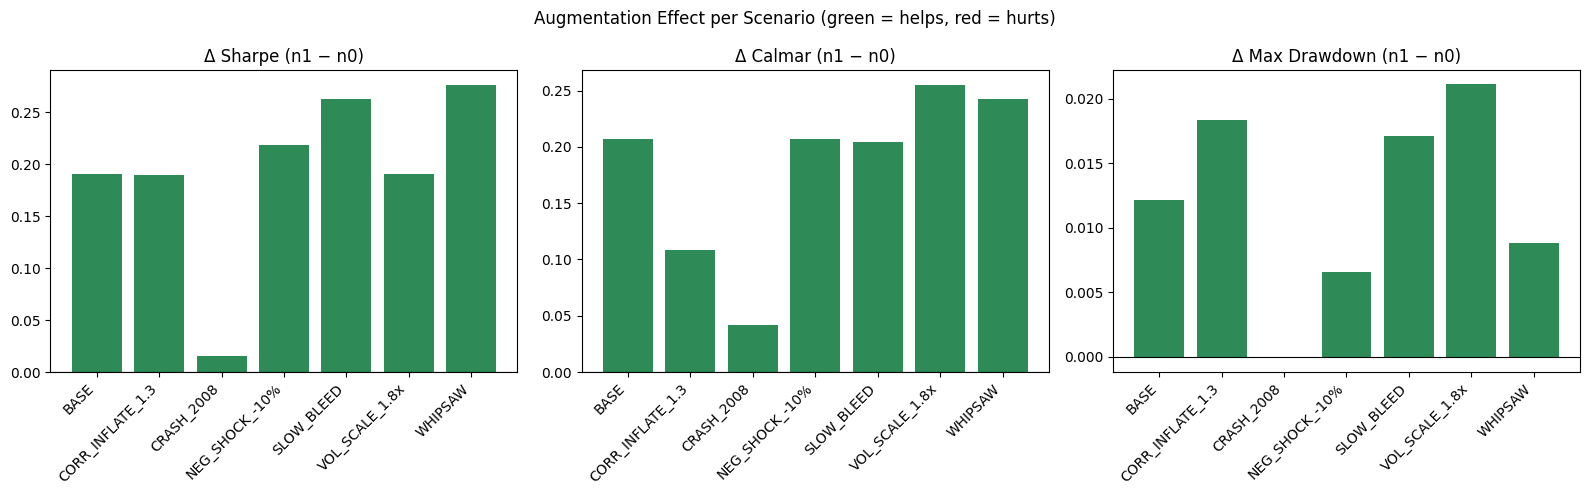

In [12]:
comp["Δ_sharpe"] = comp["sharpe_n1"]      - comp["sharpe_n0"]
comp["Δ_calmar"]  = comp["calmar_n1"]      - comp["calmar_n0"]
comp["Δ_CVaR"]    = comp["CVaR_5%_n1"]     - comp["CVaR_5%_n0"]
comp["Δ_max_dd"]  = comp["max_drawdown_n1"] - comp["max_drawdown_n0"]
comp = comp.sort_values("bucket").reset_index(drop=True)

print("Shock Test: n=0 (baseline) vs n=1 (augmented), median across rolling windows\n")
display_cols = ["bucket","sharpe_n0","sharpe_n1","Δ_sharpe",
                "calmar_n0","calmar_n1","Δ_calmar",
                "CVaR_5%_n0","CVaR_5%_n1","Δ_CVaR",
                "max_drawdown_n0","max_drawdown_n1","Δ_max_dd"]
print(comp[display_cols].round(4).to_string(index=False))

hurts = comp[comp["Δ_sharpe"] < 0]["bucket"].tolist()
helps = comp[comp["Δ_sharpe"] > 0]["bucket"].tolist()


# Visualise: one subplot per metric, one bar per scenario
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, ylabel in zip(
    axes,
    ["Δ_sharpe", "Δ_calmar", "Δ_max_dd"],
    ["Δ Sharpe (n1 − n0)", "Δ Calmar (n1 − n0)", "Δ Max Drawdown (n1 − n0)"],
):
    colors_bar = ["seagreen" if v >= 0 else "tomato" for v in comp[col]]
    ax.bar(comp["bucket"], comp[col], color=colors_bar)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(ylabel)
    ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")
plt.suptitle("Augmentation Effect per Scenario (green = helps, red = hurts)")
plt.tight_layout()
plt.show()


In [13]:
comp = aggregated_results[0][1][["bucket"]].copy()
for n, agg in aggregated_results:
    renamed = agg[["bucket"] + metrics].rename(
        columns={m: f"{m}_n{n}" for m in metrics}
    )
    comp = comp.merge(renamed, on="bucket")

print(comp)

             bucket  sharpe_n0  calmar_n0  CVaR_5%_n0  max_drawdown_n0  \
0              BASE   0.427379   0.400574   -0.021562        -0.156508   
1  CORR_INFLATE_1.3   0.452051   0.478756   -0.018669        -0.138290   
2        CRASH_2008   1.100035   3.814665   -0.247218        -0.907070   
3    NEG_SHOCK_-10%  -0.176886  -0.163989   -0.027207        -0.216242   
4        SLOW_BLEED  -0.292111  -0.228645   -0.021830        -0.216090   
5    VOL_SCALE_1.8x   0.427379   0.410267   -0.038812        -0.268647   
6           WHIPSAW   0.002536   0.002788   -0.023044        -0.194460   

   sharpe_n1  calmar_n1  CVaR_5%_n1  max_drawdown_n1  sharpe_n2  ...  \
0   0.617874   0.607764   -0.022673        -0.144376   0.554046  ...   
1   0.641809   0.587476   -0.019977        -0.119904   0.566329  ...   
2   1.115156   3.856255   -0.247127        -0.907185   1.116091  ...   
3   0.041862   0.042869   -0.027948        -0.209646   0.060329  ...   
4  -0.029165  -0.024123   -0.022946        -0.1

Shock Test: n=0 (baseline) vs n=5 (augmented),median across rolling windows

          bucket  sharpe_n0  sharpe_n5  Δ_sharpe  calmar_n0  calmar_n5  Δ_calmar  CVaR_5%_n0  CVaR_5%_n5  Δ_CVaR  max_drawdown_n0  max_drawdown_n5  Δ_max_dd
            BASE     0.4274     0.6048    0.1775     0.4006     0.5420    0.1415     -0.0216     -0.0231 -0.0015          -0.1565          -0.1444    0.0121
CORR_INFLATE_1.3     0.4521     0.6395    0.1874     0.4788     0.5324    0.0537     -0.0187     -0.0202 -0.0015          -0.1383          -0.1269    0.0114
      CRASH_2008     1.1000     1.1175    0.0174     3.8147     3.8704    0.0558     -0.2472     -0.2472 -0.0000          -0.9071          -0.9070    0.0000
  NEG_SHOCK_-10%    -0.1769     0.0536    0.2305    -0.1640     0.0448    0.2088     -0.0272     -0.0292 -0.0020          -0.2162          -0.2161    0.0001
      SLOW_BLEED    -0.2921    -0.0080    0.2842    -0.2286    -0.0054    0.2233     -0.0218     -0.0236 -0.0018          -0.2161         

/var/folders/1n/n4qv89sn37l7_jng77dbmgfh0000gn/T/ipykernel_30948/664032534.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")
/var/folders/1n/n4qv89sn37l7_jng77dbmgfh0000gn/T/ipykernel_30948/664032534.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")
/var/folders/1n/n4qv89sn37l7_jng77dbmgfh0000gn/T/ipykernel_30948/664032534.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")


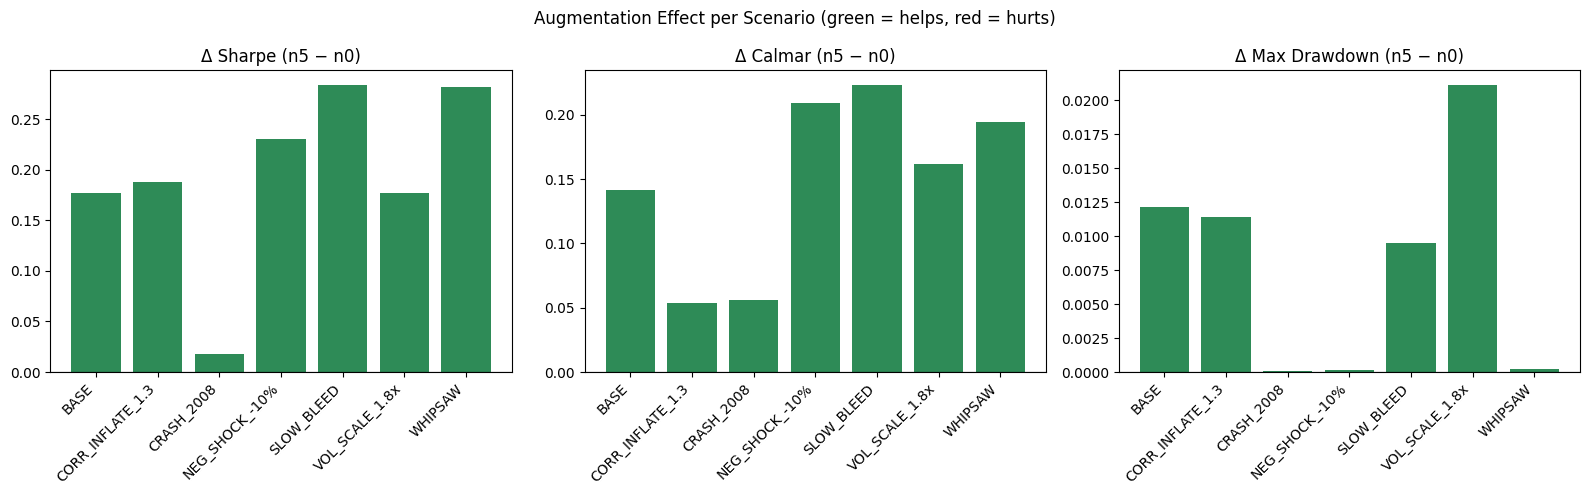

In [14]:
comp["Δ_sharpe"]  = comp["sharpe_n5"]      - comp["sharpe_n0"]
comp["Δ_calmar"]  = comp["calmar_n5"]      - comp["calmar_n0"]
comp["Δ_CVaR"]    = comp["CVaR_5%_n5"]     - comp["CVaR_5%_n0"]
comp["Δ_max_dd"]  = comp["max_drawdown_n5"] - comp["max_drawdown_n0"]
comp = comp.sort_values("bucket").reset_index(drop=True)

print("Shock Test: n=0 (baseline) vs n=5 (augmented),median across rolling windows\n")
display_cols = ["bucket","sharpe_n0","sharpe_n5","Δ_sharpe",
                "calmar_n0","calmar_n5","Δ_calmar",
                "CVaR_5%_n0","CVaR_5%_n5","Δ_CVaR",
                "max_drawdown_n0","max_drawdown_n5","Δ_max_dd"]
print(comp[display_cols].round(4).to_string(index=False))

hurts = comp[comp["Δ_sharpe"] < 0]["bucket"].tolist()
helps = comp[comp["Δ_sharpe"] > 0]["bucket"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, ylabel in zip(
    axes,
    ["Δ_sharpe", "Δ_calmar", "Δ_max_dd"],
    ["Δ Sharpe (n5 − n0)", "Δ Calmar (n5 − n0)", "Δ Max Drawdown (n5 − n0)"],
):
    colors_bar = ["seagreen" if v >= 0 else "tomato" for v in comp[col]]
    ax.bar(comp["bucket"], comp[col], color=colors_bar)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(ylabel)
    ax.set_xticklabels(comp["bucket"], rotation=45, ha="right")
plt.suptitle("Augmentation Effect per Scenario (green = helps, red = hurts)")
plt.tight_layout()
plt.show()


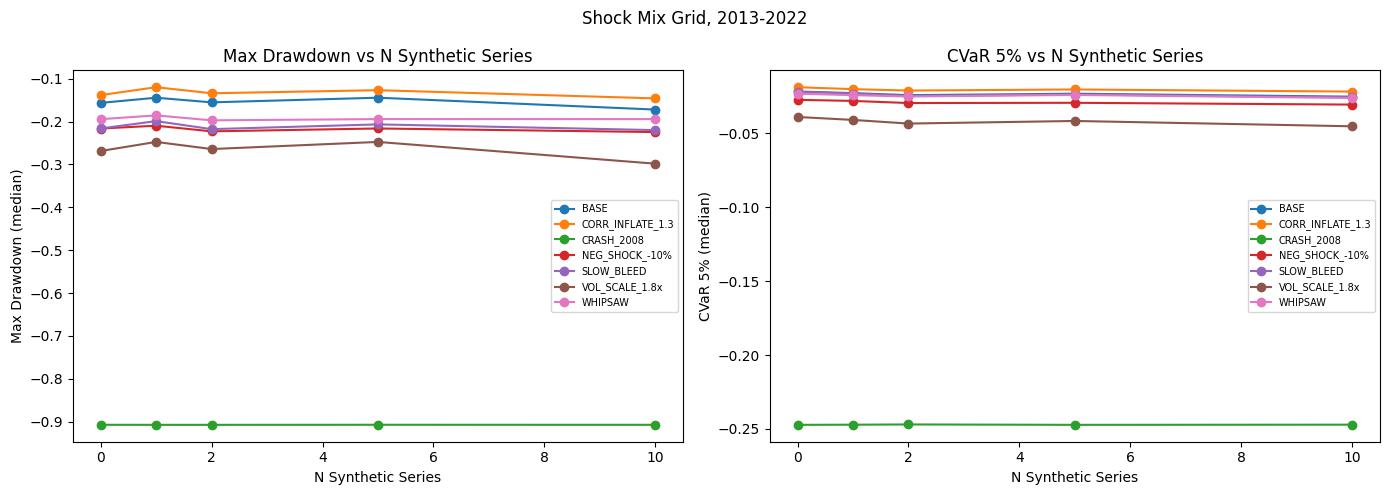

In [15]:
SHOCK_MIX_GRID = [0, 1, 2, 5, 10]
shock_mix_rows = []

for n in SHOCK_MIX_GRID:
    report = shock_test(
        real_prices=df_real, synth_pools=synth_pools, asset_cols=ASSET_COLS,
        n_synth_series=n, lookback_window=SHOCK_LOOKBACK,
        investment_window=SHOCK_INVEST, scenarios=CUSTOM_SCENARIOS,
    )
    agg = pd.concat(report).groupby("bucket").median(numeric_only=True).reset_index()
    agg["n_synth_series"] = n
    shock_mix_rows.append(agg)

shock_mix = pd.concat(shock_mix_rows, ignore_index=True)
scenarios  = shock_mix["bucket"].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for scenario in scenarios:
    sub = shock_mix[shock_mix["bucket"] == scenario].sort_values("n_synth_series")
    axes[0].plot(sub["n_synth_series"], sub["max_drawdown"], marker="o", label=scenario)
    axes[1].plot(sub["n_synth_series"], sub["CVaR_5%"], marker="o", label=scenario)

for ax, ylabel in zip(axes, ["Max Drawdown (median)", "CVaR 5% (median)"]):
    ax.set_xlabel("N Synthetic Series")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)

axes[0].set_title("Max Drawdown vs N Synthetic Series")
axes[1].set_title("CVaR 5% vs N Synthetic Series")
plt.suptitle("Shock Mix Grid, 2013-2022")
plt.tight_layout()
plt.show()


### Third experiment: Long-Short allowed

In the previous experiments I did not allow for shorts, now in theory by allowing for shorts we should be able to improve sharpe ratio

/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(obj, cons).solve(solver="ECOS")
/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(obj, cons).solve(solver="ECOS")
/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(obj, cons).solve(solver="ECOS")
/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve w

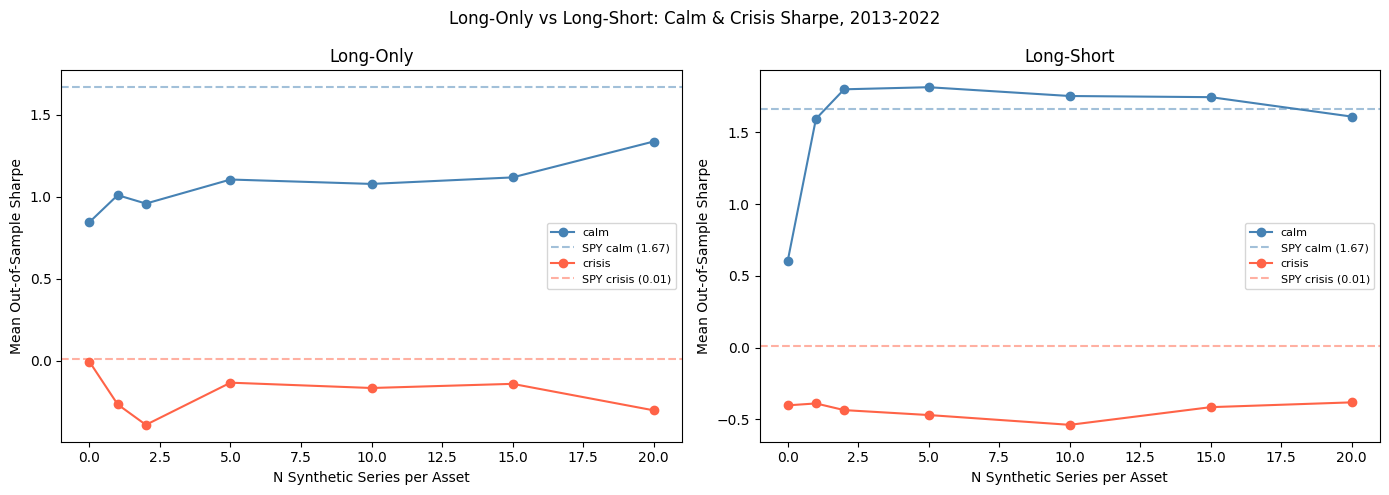

In [16]:
ls_results = []

for start_idx in range(0, len(real_rets) - LOOKBACK - INVEST, STEP):
    test_start_idx = start_idx + LOOKBACK
    test_end_idx = test_start_idx + INVEST
    test_start_date = real_rets.index[test_start_idx]
    test_end_date = real_rets.index[test_end_idx - 1]
    
    regime = classify_regime(test_start_date, test_end_date)

    window_prices = df_real.iloc[start_idx: test_end_idx + 1]
    window_result = portfolio_experiment(
        real_prices=window_prices, synth_pools=synth_pools,
        asset_cols=ASSET_COLS, mix_grid=MIX_GRID,
        lookback_window=LOOKBACK, investment_window=INVEST,
        allow_short=True, seed=42,
    )
    window_result["regime"]     = regime
    window_result["test_start"] = test_start_date
    ls_results.append(window_result)

ls_results = pd.concat(ls_results, ignore_index=True)

lo_agg = results.groupby(["regime", "n_synth_series"])["sharpe"].mean().reset_index()
ls_agg = ls_results.groupby(["regime", "n_synth_series"])["sharpe"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"calm": "steelblue", "crisis": "tomato"}

spy_by_regime = results.groupby("regime")["spy_sharpe"].mean()
for regime in ["calm", "crisis"]:
    lo = lo_agg[lo_agg["regime"] == regime].sort_values("n_synth_series")
    ls = ls_agg[ls_agg["regime"] == regime].sort_values("n_synth_series")
    c  = colors[regime]
    if not lo.empty: axes[0].plot(lo["n_synth_series"], lo["sharpe"], marker="o", color=c, label=regime)
    if not ls.empty: axes[1].plot(ls["n_synth_series"], ls["sharpe"], marker="o", color=c, label=regime)
    if regime in spy_by_regime.index:
        sr = float(spy_by_regime[regime])
        for ax in axes:
            ax.axhline(sr, linestyle="--", color=c, alpha=0.5, label=f"SPY {regime} ({sr:.2f})")

for ax in axes:
    ax.set_xlabel("N Synthetic Series per Asset")
    ax.set_ylabel("Mean Out-of-Sample Sharpe")
    ax.legend(fontsize=8)

axes[0].set_title("Long-Only")
axes[1].set_title("Long-Short")
plt.suptitle("Long-Only vs Long-Short: Calm & Crisis Sharpe, 2013-2022")
plt.tight_layout()
plt.show()



/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(obj, cons).solve(solver="ECOS")
/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(obj, cons).solve(solver="ECOS")
/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(obj, cons).solve(solver="ECOS")
/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve w

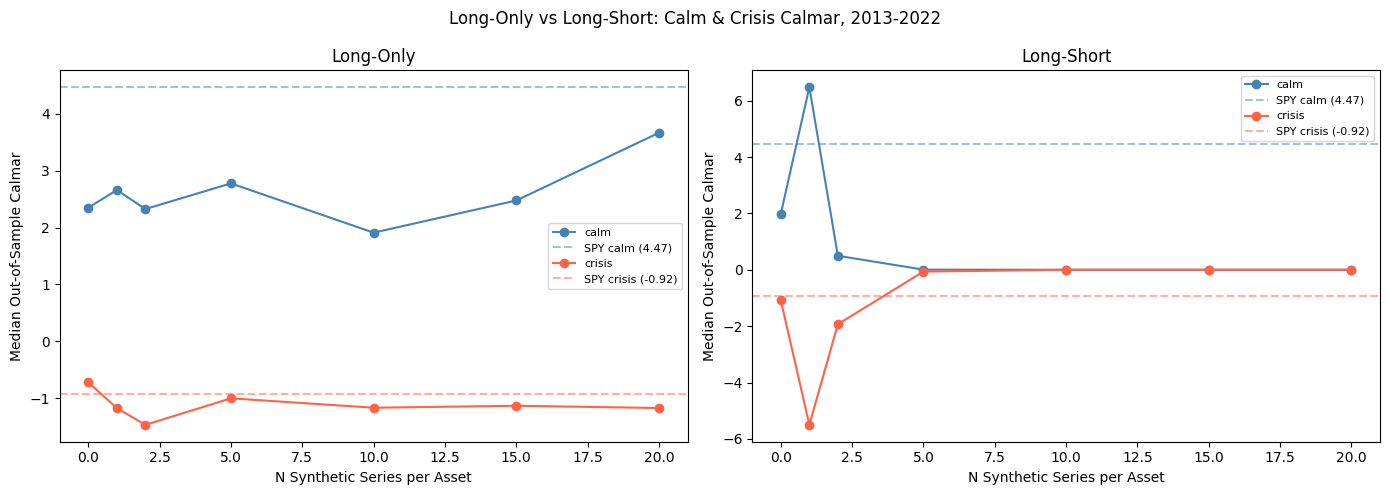

In [17]:
ls_results = []

for start_idx in range(0, len(real_rets) - LOOKBACK - INVEST, STEP):
    test_start_idx = start_idx + LOOKBACK
    test_end_idx = test_start_idx + INVEST
    test_start_date = real_rets.index[test_start_idx]
    test_end_date = real_rets.index[test_end_idx - 1]
    
    regime = classify_regime(test_start_date, test_end_date)

    window_prices = df_real.iloc[start_idx: test_end_idx + 1]
    window_result = portfolio_experiment(
        real_prices=window_prices, synth_pools=synth_pools,
        asset_cols=ASSET_COLS, mix_grid=MIX_GRID,
        lookback_window=LOOKBACK, investment_window=INVEST,
        allow_short=True, seed=42,
    )
    window_result["regime"]     = regime
    window_result["test_start"] = test_start_date
    ls_results.append(window_result)

ls_results = pd.concat(ls_results, ignore_index=True)

lo_agg = results.groupby(["regime", "n_synth_series"])["calmar"].median().reset_index()
ls_agg = ls_results.groupby(["regime", "n_synth_series"])["calmar"].median().reset_index()



fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"calm": "steelblue", "crisis": "tomato"}

spy_by_regime = results.groupby("regime")["spy_calmar"].median()

for regime in ["calm", "crisis"]:
    lo = lo_agg[lo_agg["regime"] == regime].sort_values("n_synth_series")
    ls = ls_agg[ls_agg["regime"] == regime].sort_values("n_synth_series")
    c  = colors[regime]
    if not lo.empty: axes[0].plot(lo["n_synth_series"], lo["calmar"], marker="o", color=c, label=regime)
    if not ls.empty: axes[1].plot(ls["n_synth_series"], ls["calmar"], marker="o", color=c, label=regime)
    if regime in spy_by_regime.index:
        sr = float(spy_by_regime[regime])
        for ax in axes:
            ax.axhline(sr, linestyle="--", color=c, alpha=0.5, label=f"SPY {regime} ({sr:.2f})")

for ax in axes:
    ax.set_xlabel("N Synthetic Series per Asset")
    ax.set_ylabel("Median Out-of-Sample Calmar")
    ax.legend(fontsize=8)

axes[0].set_title("Long-Only")
axes[1].set_title("Long-Short")
plt.suptitle("Long-Only vs Long-Short: Calm & Crisis Calmar, 2013-2022")
plt.tight_layout()
plt.show()


Since the augmentation draws the n columns at random when creating the augmented matrix this could cause some noise. To reduce the noise we use different seeds and average over them:

sharpe


,regime,n_synth_series,mean,sem
0,calm,0,0.8455,0.0946
1,calm,1,1.0094,0.0981
2,calm,2,0.9582,0.0921
3,calm,5,1.1046,0.0873
4,calm,10,1.0778,0.0897
5,calm,15,1.1174,0.0869
6,calm,20,1.3359,0.0906
7,crisis,0,-0.0049,0.2046
8,crisis,1,-0.2646,0.1590
9,crisis,2,-0.3890,0.1418


calmar


,regime,n_synth_series,mean,std,count,sem
0,calm,0,2.3501,0.0,5,0.0
1,calm,1,2.6599,0.0,5,0.0
2,calm,2,2.3254,0.0,5,0.0
3,calm,5,2.7770,0.0,5,0.0
4,calm,10,1.9106,0.0,5,0.0
5,calm,15,2.4761,0.0,5,0.0
6,calm,20,3.6667,0.0,5,0.0
7,crisis,0,-0.7214,0.0,5,0.0
8,crisis,1,-1.1743,0.0,5,0.0
9,crisis,2,-1.4680,0.0,5,0.0


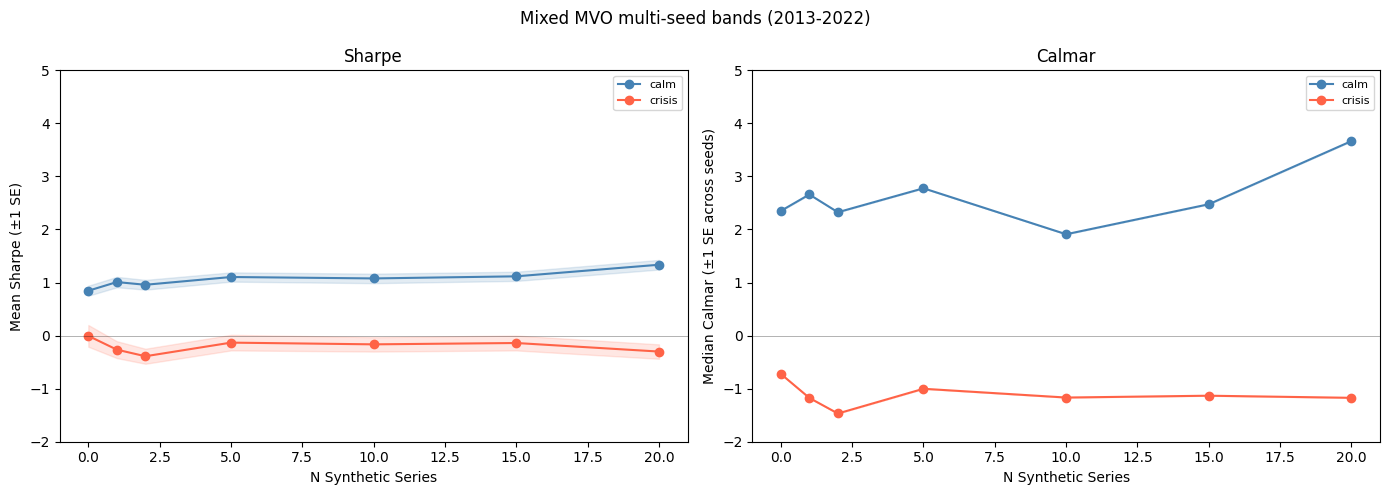

In [29]:
SEEDS = [42, 43, 1034, 45, 88]
seed_results = []

for s in SEEDS:
    for start_idx in range(0, len(real_rets) - LOOKBACK - INVEST, STEP):
        test_start_idx = start_idx + LOOKBACK
        test_end_idx = test_start_idx + INVEST
        test_start_date = real_rets.index[test_start_idx]
        test_end_date = real_rets.index[test_end_idx - 1]
        regime = classify_regime(test_start_date, test_end_date)

        window_prices = df_real.iloc[start_idx: test_end_idx + 1]
        window_result = portfolio_experiment(
            real_prices=window_prices, synth_pools=synth_pools,
            asset_cols=ASSET_COLS, mix_grid=MIX_GRID,
            lookback_window=LOOKBACK, investment_window=INVEST, seed=s,
        )
        window_result["regime"] = regime
        window_result["test_start"] = test_start_date
        window_result["seed"] = s
        seed_results.append(window_result)

results_multiseed = pd.concat(seed_results, ignore_index=True)

colors = {"calm": "steelblue", "crisis": "tomato"}
BAND_YLIM = (-2.0, 5.0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metric, ylabel in [
    (axes[0], "sharpe", "Mean Sharpe (±1 SE)"),
    (axes[1], "calmar", "Median Calmar (±1 SE across seeds)"),
]:
    if metric == "sharpe":
        agg = results_multiseed.groupby(["regime", "n_synth_series"])[metric].agg(["mean", "sem"]).reset_index()
        y, e = "mean", "sem"
    else:
        per = results_multiseed.groupby(["seed", "regime", "n_synth_series"])[metric].median().reset_index()
        agg = per.groupby(["regime", "n_synth_series"])[metric].agg(["mean", "std", "count"]).reset_index()
        agg["sem"] = agg["std"] / np.sqrt(agg["count"])
        y, e = "mean", "sem"
    print(metric)
    display(agg.round(4))
    for regime, grp in agg.groupby("regime"):
        grp = grp.sort_values("n_synth_series")
        c = colors[regime]
        ax.plot(grp["n_synth_series"], grp[y], marker="o", color=c, label=regime)
        ax.fill_between(grp["n_synth_series"], grp[y] - grp[e], grp[y] + grp[e], alpha=0.15, color=c)
    ax.axhline(0, color="black", lw=0.6, alpha=0.35)
    ax.set_ylim(*BAND_YLIM)
    ax.set_xlabel("N Synthetic Series")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
axes[1].tick_params(labelleft=True)
axes[0].set_title("Sharpe")
axes[1].set_title("Calmar")
plt.suptitle("Mixed MVO multi-seed bands (2013-2022)")
plt.tight_layout()
plt.show()


### Sixth Experiment: Daily Rebalanced MVO 

The daily rebalancing MVO will resolve the MVO every trading day looking at the most recent 252 days of trading. That means it will slowly adjust as we enter a crisis period for example the covid crash in 2020. Preferably we would want to see augementation helping the adoption by giving us synthetic paths that are also going through a crisis, leading to a growing effect on our covariance estimate and thus our MVO.

We do a couple different comparisons as well as using the S&P as a benchmark using a buy and hold. However this index obviously performed quite well over the past decade so seeing a slightly worse performance is expected. Really we aim more to see whether the augmentation beats an unaugmented MVO. 

In [19]:
real_rets_full = pct_returns(df_real)

N_TRAIN_A = len(real_rets_full.loc[:'2017-12-31'])
N_TEST_A = len(real_rets_full) - N_TRAIN_A

N_TRAIN_B = len(real_rets_full.loc[:'2019-12-31'])
N_TEST_B = len(real_rets_full) - N_TRAIN_B

print(f"Split A, Train: {real_rets_full.index[0].date()} - {real_rets_full.index[N_TRAIN_A-1].date()} ({N_TRAIN_A} days)")
print(f"Split A, Test : {real_rets_full.index[N_TRAIN_A].date()} - {real_rets_full.index[-1].date()} ({N_TEST_A} days)")
print()
print(f"Split B, Train: {real_rets_full.index[0].date()} - {real_rets_full.index[N_TRAIN_B-1].date()} ({N_TRAIN_B} days)")
print(f"Split B, Test : {real_rets_full.index[N_TRAIN_B].date()} - {real_rets_full.index[-1].date()} ({N_TEST_B} days)")


Split A, Train: 2013-01-02 - 2017-12-29 (1303 days)
Split A, Test : 2018-01-01 - 2022-08-31 (1218 days)

Split B, Train: 2013-01-02 - 2019-12-31 (1825 days)
Split B, Test : 2020-01-01 - 2022-08-31 (696 days)


In [20]:
LOOKBACK_DAILY = 252
N_SYNTH_LIST = [0,1,2, 5, 20]
SEED = 42

daily_port_rets = {n: [] for n in N_SYNTH_LIST}
daily_dates = []

for t in range(N_TRAIN_B, N_TRAIN_B + N_TEST_B):
    train_window = real_rets_full.iloc[t - LOOKBACK_DAILY : t]
    test_day     = real_rets_full.iloc[t]
    daily_dates.append(real_rets_full.index[t])

    for n in N_SYNTH_LIST:
        use_train, n_draw = mix_train_matrix(
            train_window.values, synth_pools, ASSET_COLS,
            n_synth_series=int(n), seed=SEED,
            train_index = train_window.index
        )
        w = mean_var_weights(use_train, allow_short=False)
        w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
        daily_port_rets[n].append(float(test_day.values @ w))



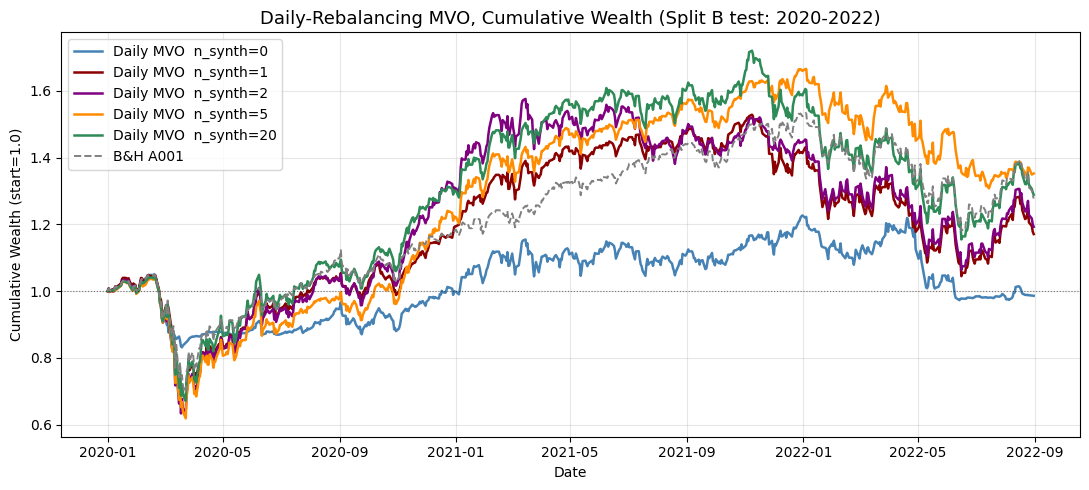

In [21]:
wealth = {
    n: (1 + pd.Series(daily_port_rets[n], index=daily_dates)).cumprod()
    for n in N_SYNTH_LIST
}
spy_rets_daily = real_rets_full[ASSET_COLS[0]].iloc[N_TRAIN_B : N_TRAIN_B + N_TEST_B]
spy_rets_daily.index = daily_dates
wealth_spy_daily  = (1 + spy_rets_daily).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
d_colors = {0: "steelblue", 1: "darkred", 2: "purple", 5: "darkorange", 20: "seagreen"}
for n in N_SYNTH_LIST:
    ax.plot(wealth[n], label=f"Daily MVO  n_synth={n}", color=d_colors[n], linewidth=1.8)
ax.plot(wealth_spy_daily, label=f"B&H {ASSET_COLS[0]}", color="gray",
        linestyle="--", linewidth=1.4)
ax.axhline(1.0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_title("Daily-Rebalancing MVO, Cumulative Wealth (Split B test: 2020-2022)", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Wealth (start=1.0)")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [22]:
rows = []
for n in N_SYNTH_LIST:
    port = pd.Series(np.asarray(daily_port_rets[n])) 
    rows.append(summarize_portfolio(port, label=f"Daily MVO n_synth={n}"))
rows.append(summarize_portfolio(pd.Series(spy_rets_daily.values), label=f"B&H {ASSET_COLS[0]}"))
print(pd.DataFrame(rows).set_index("bucket").to_string())

                        sharpe    calmar  max_drawdown    VaR_5%   CVaR_5%    ann_mu    ann_sd  n_obs
bucket                                                                                               
Daily MVO n_synth=0   0.061609  0.052804     -0.208237 -0.019279 -0.028487  0.010996  0.178477    696
Daily MVO n_synth=1   0.357479  0.241912     -0.359244 -0.024292 -0.036563  0.086905  0.243107    696
Daily MVO n_synth=2   0.364319  0.280927     -0.391812 -0.028545 -0.044636  0.110071  0.302127    696
Daily MVO n_synth=5   0.538917  0.363407     -0.404310 -0.024260 -0.041932  0.146929  0.272638    696
Daily MVO n_synth=20  0.459411  0.382665     -0.355737 -0.027335 -0.044021  0.136128  0.296310    696
B&H A001              0.480422  0.356423     -0.337903 -0.024249 -0.039704  0.120436  0.250689    696


Now do Split A from 2018 - 2022 

In [23]:
daily_port_rets_A = {n: [] for n in N_SYNTH_LIST}
daily_dates_A = []

for t in range(N_TRAIN_A, N_TRAIN_A + N_TEST_A):
    train_window = real_rets_full.iloc[t - LOOKBACK_DAILY : t]
    test_day = real_rets_full.iloc[t]
    daily_dates_A.append(real_rets_full.index[t])

    for n in N_SYNTH_LIST:
        use_train, n_draw = mix_train_matrix(
            train_window.values, synth_pools, ASSET_COLS,
            n_synth_series=int(n), seed=SEED, 
            train_index = train_window.index
        )
        w = mean_var_weights(use_train, allow_short=False)
        w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
        daily_port_rets_A[n].append(float(test_day.values @ w))

print(f"Done. {N_TEST_A} test days x {len(N_SYNTH_LIST)} n_synth = {N_TEST_A * len(N_SYNTH_LIST)} solves.")


Done. 1218 test days x 5 n_synth = 6090 solves.


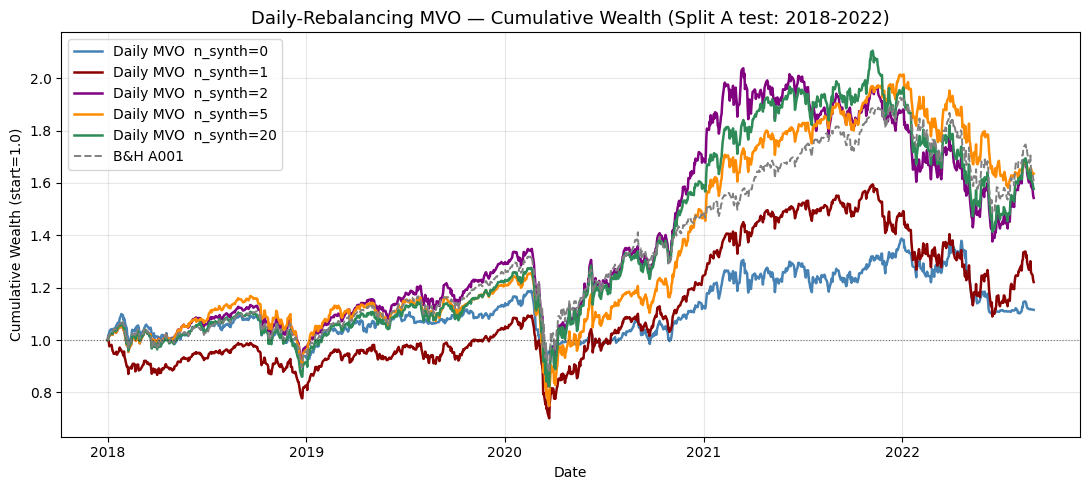

In [24]:
wealth_A = {
    n: (1 + pd.Series(daily_port_rets_A[n], index=daily_dates_A)).cumprod()
    for n in N_SYNTH_LIST
}
spy_rets_A_daily = real_rets_full[ASSET_COLS[0]].iloc[N_TRAIN_A : N_TRAIN_A + N_TEST_A]
spy_rets_A_daily.index = daily_dates_A
wealth_spy_A  = (1 + spy_rets_A_daily).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
for n in N_SYNTH_LIST:
    ax.plot(wealth_A[n], label=f"Daily MVO  n_synth={n}", color=d_colors[n], linewidth=1.8)
ax.plot(wealth_spy_A, label=f"B&H {ASSET_COLS[0]}", color="gray",
        linestyle="--", linewidth=1.4)
ax.axhline(1.0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_title("Daily-Rebalancing MVO — Cumulative Wealth (Split A test: 2018-2022)", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Wealth (start=1.0)")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [25]:
rows = []
for n in N_SYNTH_LIST:
    port = pd.Series(daily_port_rets_A[n], index=daily_dates_A)
    rows.append(summarize_portfolio(port, label=f"Daily MVO n_synth={n}"))

rows.append(summarize_portfolio(spy_rets_A_daily, label=f"B&H {ASSET_COLS[0]}"))

print(pd.DataFrame(rows).set_index("bucket").to_string())

                        sharpe    calmar  max_drawdown    VaR_5%   CVaR_5%    ann_mu    ann_sd  n_obs
bucket                                                                                               
Daily MVO n_synth=0   0.222431  0.168615     -0.208237 -0.016860 -0.025468  0.035112  0.157855   1218
Daily MVO n_synth=1   0.302591  0.177076     -0.359244 -0.021878 -0.032183  0.063614  0.210230   1218
Daily MVO n_synth=2   0.486787  0.308611     -0.391812 -0.023327 -0.037270  0.120917  0.248399   1218
Daily MVO n_synth=5   0.559353  0.317602     -0.404310 -0.020651 -0.035345  0.128410  0.229568   1218
Daily MVO n_synth=20  0.508734  0.349700     -0.355737 -0.022603 -0.036805  0.124401  0.244531   1218
B&H A001              0.568697  0.357540     -0.337903 -0.020613 -0.033764  0.120814  0.212440   1218


### Same but for a larger (full) period to see if there's a difference

In [26]:
FULL_TEST_START = LOOKBACK_DAILY                      
FULL_TEST_END = len(real_rets_full)                  

daily_port_rets_full_run = {n: [] for n in N_SYNTH_LIST}
daily_dates_full_run = []

for t in range(FULL_TEST_START, FULL_TEST_END):
    train_window = real_rets_full.iloc[t - LOOKBACK_DAILY : t]
    test_day = real_rets_full.iloc[t]
    daily_dates_full_run.append(real_rets_full.index[t])

    for n in N_SYNTH_LIST:
        use_train, n_draw = mix_train_matrix(
            train_window.values, synth_pools, ASSET_COLS,
            n_synth_series=int(n), seed=SEED,
            train_index = train_window.index
        )
        w = mean_var_weights(use_train, allow_short=False)
        w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
        daily_port_rets_full_run[n].append(float(test_day.values @ w))

n_solves = (FULL_TEST_END - FULL_TEST_START) * len(N_SYNTH_LIST)
print(f"Done. {FULL_TEST_END - FULL_TEST_START} test days x {len(N_SYNTH_LIST)} n_synth = {n_solves} solves.")


KeyboardInterrupt: 

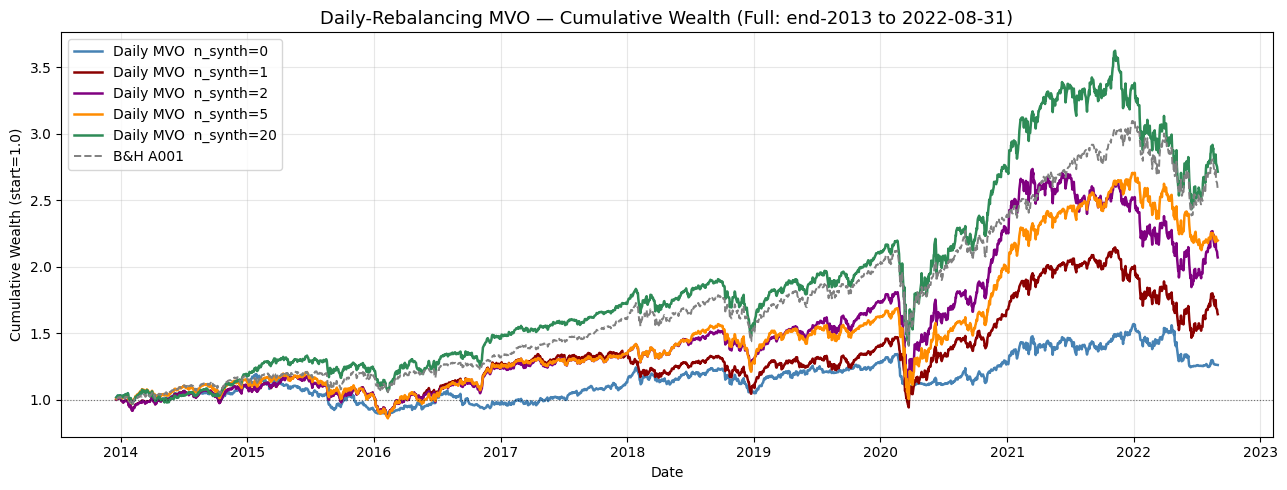

In [ ]:
wealth_full_run = {
    n: (1 + pd.Series(daily_port_rets_full_run[n], index=daily_dates_full_run)).cumprod()
    for n in N_SYNTH_LIST
}
spy_rets_full_run = real_rets_full[ASSET_COLS[0]].iloc[FULL_TEST_START:FULL_TEST_END]
spy_rets_full_run.index = daily_dates_full_run
wealth_spy_full = (1 + spy_rets_full_run).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
for n in N_SYNTH_LIST:
    ax.plot(wealth_full_run[n], label=f"Daily MVO  n_synth={n}",
            color=d_colors[n], linewidth=1.8)
ax.plot(wealth_spy_full, label=f"B&H {ASSET_COLS[0]}", color="gray",
        linestyle="--", linewidth=1.4)
ax.axhline(1.0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_title("Daily-Rebalancing MVO — Cumulative Wealth (Full: end-2013 to 2022-08-31)", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Wealth (start=1.0)")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
rows = []
for n in N_SYNTH_LIST:
    port = pd.Series(np.asarray(daily_port_rets_full_run[n]))    
    rows.append(summarize_portfolio(port, label=f"Daily MVO n_synth={n}"))
rows.append(summarize_portfolio(pd.Series(spy_rets_full_run.values), label=f"B&H {ASSET_COLS[0]}"))
print(pd.DataFrame(rows).set_index("bucket").to_string())

                        sharpe    calmar  max_drawdown    VaR_5%   CVaR_5%    ann_mu    ann_sd  n_obs
bucket                                                                                               
Daily MVO n_synth=0   0.251609  0.146789     -0.247422 -0.015250 -0.023216  0.036319  0.144346   2269
Daily MVO n_synth=1   0.393930  0.200268     -0.359244 -0.018954 -0.027935  0.071945  0.182634   2269
Daily MVO n_synth=2   0.495686  0.261154     -0.391812 -0.019589 -0.030926  0.102323  0.206427   2269
Daily MVO n_synth=5   0.551922  0.262317     -0.404310 -0.018059 -0.028918  0.106057  0.192160   2269
Daily MVO n_synth=20  0.651558  0.369353     -0.355737 -0.019031 -0.030323  0.131393  0.201659   2269
B&H A001              0.689146  0.357465     -0.337903 -0.016572 -0.027587  0.120788  0.175273   2269


### Seventh Experiment: Constrained MVO, checking what happens when only allowing 25% per asset to create more balanced portfolios. Will augmentation help:

In [ ]:
MAX_W = 0.25

constrained_static = {}
for n in [0,1,2, 5, 20]:
    train_rets = real_rets_full.iloc[:N_TRAIN_B]
    test_rets = real_rets_full.iloc[N_TRAIN_B:]
    use_train, n_draw = mix_train_matrix(
        train_rets.values, synth_pools, ASSET_COLS, n_synth_series=int(n), seed=42,
        train_index = train_rets.index
    )
    w = mean_var_weights(use_train, allow_short=False,
                         max_weight=MAX_W, n_assets_orig=len(ASSET_COLS), n_draw=n_draw)
    w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
    port = pd.Series(test_rets.values @ w, index=test_rets.index)
    constrained_static[n] = port
    print(f"n_synth={n:2d}  max_w={w.max():.3f}  top={ASSET_COLS[w.argmax()]}  Sharpe={sharpe_ratio(port.values):.3f}")
    print(pd.Series(w, index=ASSET_COLS).map(lambda x: f"{x:.4f}").to_string())
    print()


n_synth= 0  max_w=0.250  top=A001  Sharpe=0.364
A001    0.2500
A004    0.0000
A006    0.0000
A008    0.0000
A009    0.0000
A011    0.2500
A012    0.2500
A013    0.0000
A014    0.0000
A015    0.2500

n_synth= 1  max_w=0.250  top=A012  Sharpe=0.347
A001    0.2500
A004    0.0000
A006    0.0000
A008    0.0000
A009    0.0000
A011    0.2500
A012    0.2500
A013    0.0000
A014    0.2500
A015    0.0000

n_synth= 2  max_w=0.250  top=A012  Sharpe=0.347
A001    0.2500
A004    0.0000
A006    0.0000
A008    0.0000
A009    0.0000
A011    0.2500
A012    0.2500
A013    0.0000
A014    0.2500
A015    0.0000

n_synth= 5  max_w=0.250  top=A011  Sharpe=0.347
A001    0.2500
A004    0.0000
A006    0.0000
A008    0.0000
A009    0.0000
A011    0.2500
A012    0.2500
A013    0.0000
A014    0.2500
A015    0.0000

n_synth=20  max_w=0.250  top=A011  Sharpe=0.347
A001    0.2500
A004    0.0000
A006    0.0000
A008    0.0000
A009    0.0000
A011    0.2500
A012    0.2500
A013    0.0000
A014    0.2500
A015    0.0000



In [ ]:
constrained_daily = {n: [] for n in [0, 1, 2, 5, 20]}

for t in range(N_TRAIN_B, N_TRAIN_B + N_TEST_B):
    train_window = real_rets_full.iloc[t - 252 : t]
    test_day     = real_rets_full.iloc[t]
    for n in [0, 1, 2, 5, 20]:
        use_train, n_draw = mix_train_matrix(
            train_window.values, synth_pools, ASSET_COLS, n_synth_series=int(n), seed=42,
            train_index = train_window.index
        )
        w = mean_var_weights(use_train, allow_short=False,
                             max_weight=MAX_W, n_assets_orig=len(ASSET_COLS), n_draw=n_draw)
        w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
        constrained_daily[n].append(float(test_day.values @ w))

constrained_daily = {n: pd.Series(constrained_daily[n], index=daily_dates) for n in [0, 1, 2, 5, 20]}
print("Done.")


Done.


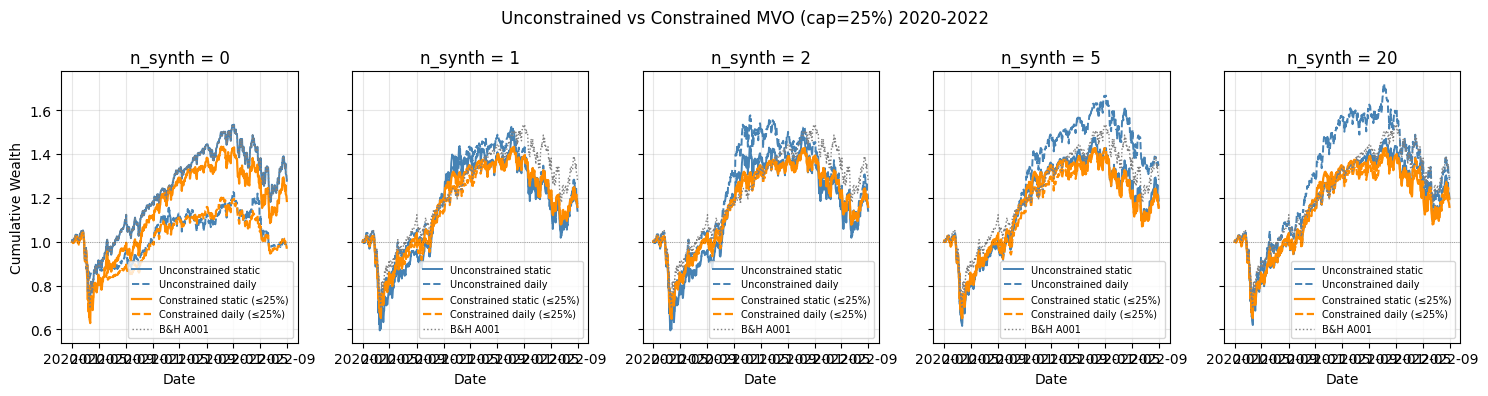

In [ ]:
static_wealth = {}
for n in [0, 1, 2, 5, 20]:
    train_rets = real_rets_full.iloc[:N_TRAIN_B]
    test_rets = real_rets_full.iloc[N_TRAIN_B : N_TRAIN_B + N_TEST_B]
    use_train, n_draw = mix_train_matrix(
        train_rets.values, synth_pools, ASSET_COLS, n_synth_series=int(n), seed=42,
        train_index = train_rets.index
    )
    w = mean_var_weights(use_train, allow_short=False)
    w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
    port = pd.Series(test_rets.values @ w, index=test_rets.index)
    static_wealth[n] = (1 + port).cumprod()

fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=True)
fig.suptitle(f"Unconstrained vs Constrained MVO (cap={MAX_W:.0%}) 2020-2022", fontsize=12)

for ax, n in zip(axes, [0, 1, 2, 5, 20]):
    ax.plot(static_wealth[n], color="steelblue", lw=1.4, ls="-",  label="Unconstrained static")
    ax.plot((1+pd.Series(daily_port_rets[n], index=daily_dates)).cumprod(),
            color="steelblue", lw=1.4, ls="--", label="Unconstrained daily")
    ax.plot((1+constrained_static[n]).cumprod(),
            color="darkorange", lw=1.6, ls="-",  label=f"Constrained static (≤{MAX_W:.0%})")
    ax.plot((1+constrained_daily[n]).cumprod(),
            color="darkorange", lw=1.6, ls="--", label=f"Constrained daily (≤{MAX_W:.0%})")
    ax.plot(wealth_spy_daily, color="gray", lw=1.0, ls=":", label=f"B&H {ASSET_COLS[0]}")
    ax.axhline(1.0, color="black", ls=":", lw=0.6, alpha=0.4)
    ax.set_title(f"n_synth = {n}"); ax.set_xlabel("Date")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Cumulative Wealth")
plt.tight_layout(); plt.show()

In [ ]:
rows = []
for n in [0, 1, 2, 5, 20]:
    pairs = [
        ("Unconstrained static", static_wealth[n].pct_change().fillna(static_wealth[n].iloc[0]-1)),
        (f"Constrained static (≤{MAX_W:.0%})",constrained_static[n]),
        ("Unconstrained daily", pd.Series(daily_port_rets[n], index=daily_dates)),
        (f"Constrained daily (≤{MAX_W:.0%})", constrained_daily[n]),
    ]
    for label, r in pairs:
        arr = r.values
        cum = float((1+r).cumprod().iloc[-1])
        mdd = float(((1+r).cumprod()/(1+r).cumprod().cummax()-1).min())
        rows.append(dict(n_synth=n, strategy=label,
                         sharpe=round(sharpe_ratio(arr),3),
                         ann_ret=round(float(arr.mean()*TRADING_DAYS),4),
                         ann_vol=round(float(arr.std(ddof=0)*np.sqrt(TRADING_DAYS)),4),
                         cum_wealth=round(cum,4), max_dd=round(mdd,4)))

print(pd.DataFrame(rows).set_index(["n_synth","strategy"]).to_string())


                                   sharpe  ann_ret  ann_vol  cum_wealth  max_dd
n_synth strategy                                                               
0       Unconstrained static        0.480   0.1204   0.2507      1.2778 -0.3379
        Constrained static (≤25%)   0.364   0.0995   0.2730      1.1856 -0.3961
        Unconstrained daily         0.062   0.0110   0.1785      0.9863 -0.2082
        Constrained daily (≤25%)   -0.012  -0.0017   0.1418      0.9678 -0.2545
1       Unconstrained static        0.311   0.0993   0.3191      1.1410 -0.4172
        Constrained static (≤25%)   0.347   0.0810   0.2336      1.1589 -0.3651
        Unconstrained daily         0.357   0.0869   0.2431      1.1711 -0.3592
        Constrained daily (≤25%)    0.363   0.0797   0.2197      1.1651 -0.3662
2       Unconstrained static        0.311   0.0993   0.3191      1.1410 -0.4172
        Constrained static (≤25%)   0.347   0.0810   0.2336      1.1589 -0.3651
        Unconstrained daily         0.36

### Eight experiment: Constrained w/ Long-Short MVO

 Now it's constrained from -25% to 25% rather than 0-25% 

In [ ]:
ls_constrained_static = {}
for n in [0, 1, 2, 5, 20]:
    train_rets = real_rets_full.iloc[:N_TRAIN_B]
    test_rets = real_rets_full.iloc[N_TRAIN_B:]
    use_train, n_draw = mix_train_matrix(
        train_rets.values, synth_pools, ASSET_COLS, n_synth_series=int(n), seed=42,
        train_index = train_rets.index
    )
    w = mean_var_weights(use_train, allow_short=True,
                         max_weight=MAX_W, n_assets_orig=len(ASSET_COLS), n_draw=n_draw)
    w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
    port = pd.Series(test_rets.values @ w, index=test_rets.index)
    ls_constrained_static[n] = port
    shorts = [ASSET_COLS[i] for i in range(len(ASSET_COLS)) if w[i] < 0]
    print(f"n_synth={n:2d}  Sharpe={sharpe_ratio(port.values):.3f}  shorts={shorts or 'none'}")

ls_constrained_daily = {n: [] for n in [0, 1, 2, 5, 20]}
for t in range(N_TRAIN_B, N_TRAIN_B + N_TEST_B):
    train_window = real_rets_full.iloc[t - 252 : t]
    test_day = real_rets_full.iloc[t]
    for n in [0, 1, 2, 5, 20]:
        use_train, n_draw = mix_train_matrix(
            train_window.values, synth_pools, ASSET_COLS, n_synth_series=int(n), seed=42,
            train_index = train_window.index
        )
        w = mean_var_weights(use_train, allow_short=True,
                             max_weight=MAX_W, n_assets_orig=len(ASSET_COLS), n_draw=n_draw)
        w = collapse_weights(w, n_assets=len(ASSET_COLS), n_draw=n_draw)
        ls_constrained_daily[n].append(float(test_day.values @ w))

ls_constrained_daily = {n: pd.Series(ls_constrained_daily[n], index=daily_dates) for n in [0, 1, 2, 5, 20]}
print("Done.")


n_synth= 0  Sharpe=0.312  shorts=['A004', 'A006', 'A014']
n_synth= 1  Sharpe=0.280  shorts=['A004', 'A006', 'A008']
n_synth= 2  Sharpe=0.280  shorts=['A004', 'A006', 'A008']
n_synth= 5  Sharpe=0.280  shorts=['A004', 'A006', 'A008']
n_synth=20  Sharpe=0.280  shorts=['A004', 'A006', 'A008']


/Users/mohanyang/Desktop/ruya/Synthetic-data-tests/evaluation/portfolio_core.py:331: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cp.Problem(obj, cons).solve(solver="ECOS")


Done.


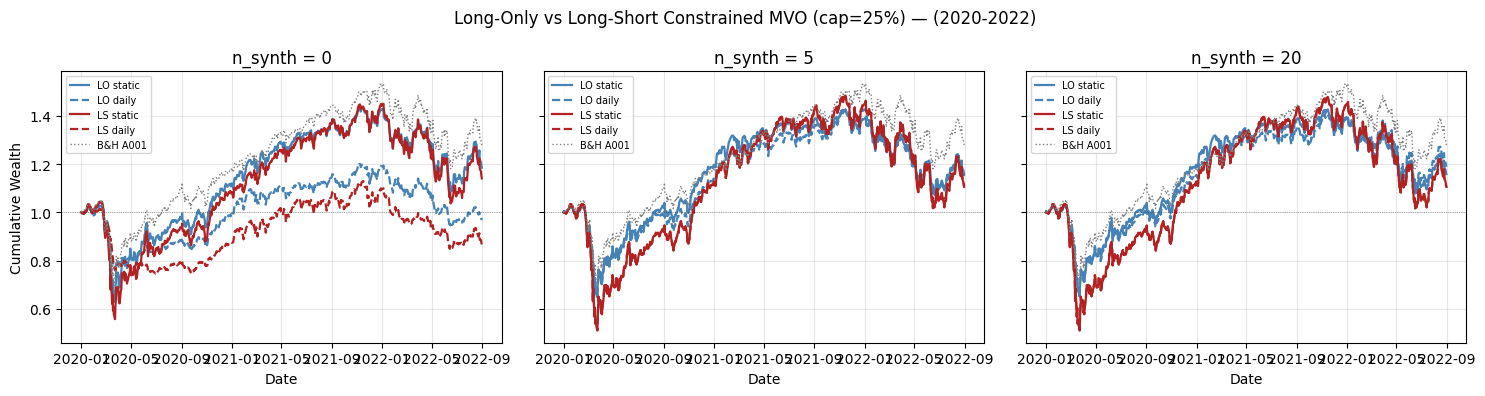

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(f"Long-Only vs Long-Short Constrained MVO (cap={MAX_W:.0%}) — (2020-2022)", fontsize=12)

for ax, n in zip(axes, [0, 5, 20]):
    ax.plot((1+constrained_static[n]).cumprod(), color="steelblue", lw=1.6, ls="-",  label="LO static")
    ax.plot((1+constrained_daily[n]).cumprod(), color="steelblue", lw=1.6, ls="--", label="LO daily")
    ax.plot((1+ls_constrained_static[n]).cumprod(),color="firebrick", lw=1.6, ls="-",  label="LS static")
    ax.plot((1+ls_constrained_daily[n]).cumprod(),color="firebrick", lw=1.6, ls="--", label="LS daily")
    ax.plot(wealth_spy_daily, color="gray", lw=1.0, ls=":", label=f"B&H {ASSET_COLS[0]}")
    ax.axhline(1.0, color="black", ls=":", lw=0.6, alpha=0.4)
    ax.set_title(f"n_synth = {n}"); ax.set_xlabel("Date")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Cumulative Wealth")
plt.tight_layout(); plt.show()


### Testing the quality of the data

During many of the tests we can see that the synthetic series tends to end up with the same solution or a similar one as well as changing between performing marginally better or worse. This could point towards reaching corner solutions (for example putting all the weight on the S&P) or noise being the main contributor towards whether it performs better or worse. To check if this is the case I run a couple of tests below that help diagnose what's happening based on the metric evaluations and methods used (mainly diagnosing MVO characteristics)

### Correlation between assets Synthetic vs Real 

MVO depends on correlations between assets in order to find the best solution. If the synthetic data is uncorrelated then in theory we would not see the same co-movement that happens during a crisis and thus the augmentation would not be that beneficial to us. Testing for covariance: 

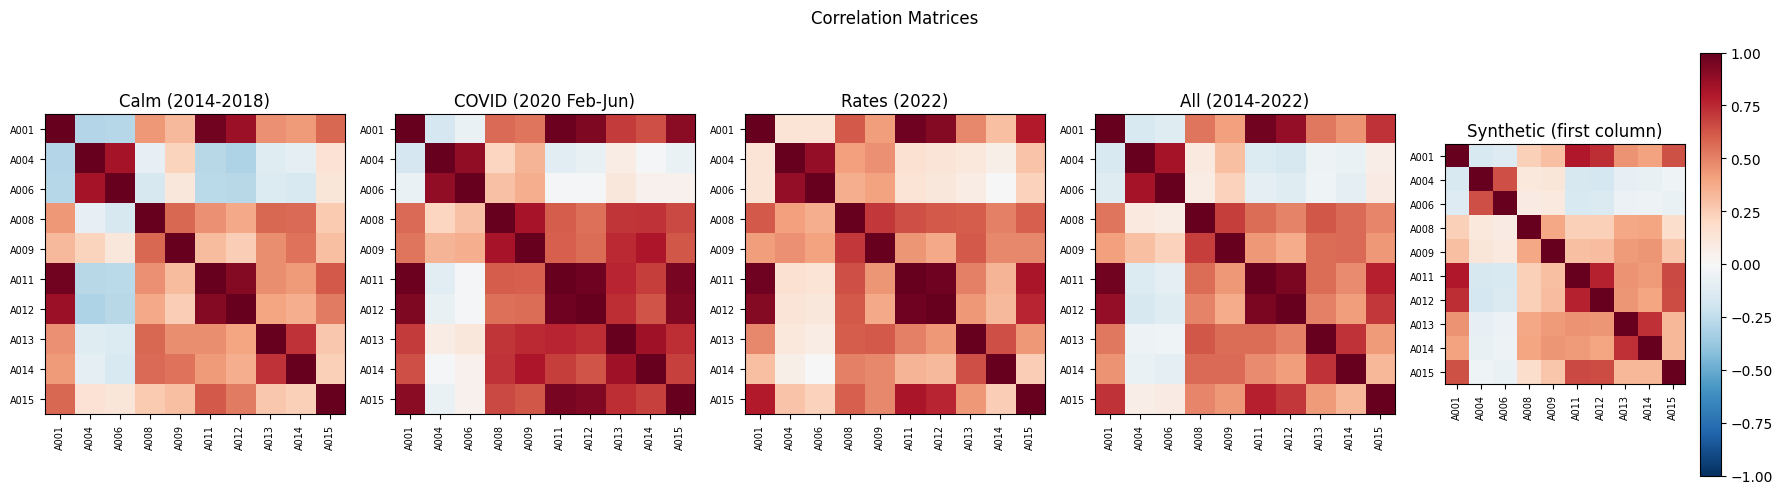

In [ ]:
def corr_matrix(rets_df):
    return rets_df.corr().values

real_rets_full_diag = pct_returns(df_real)
calm_rets = real_rets_full_diag.loc["2014-01-01":"2018-09-30"]
covid_rets = real_rets_full_diag.loc["2020-02-01":"2020-06-01"]
rates_rets = real_rets_full_diag.loc["2022-01-01":"2022-12-31"]
all_rets = real_rets_full_diag.loc["2014-01-01":"2022-08-31"]

synth_rep = pd.DataFrame({
    asset: synth_pools[asset].iloc[:,0].values[:len(real_rets_full_diag)]
    for asset in ASSET_COLS
})

corr_panels = [
    ("Calm (2014-2018)", corr_matrix(calm_rets)),
    ("COVID (2020 Feb-Jun)", corr_matrix(covid_rets)),
    ("Rates (2022)", corr_matrix(rates_rets)),
    ("All (2014-2022)", corr_matrix(all_rets)),
    ("Synthetic (first column)", corr_matrix(synth_rep)),
]
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Correlation Matrices", fontsize=12)

for ax, (title, C) in zip(axes, corr_panels):
    im = ax.imshow(C, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(title)
    ax.set_xticks(range(len(ASSET_COLS)))
    ax.set_xticklabels(ASSET_COLS, rotation=90, fontsize=7)
    ax.set_yticks(range(len(ASSET_COLS)))
    ax.set_yticklabels(ASSET_COLS, fontsize=7)

plt.colorbar(im, ax=axes[-1])
plt.tight_layout()
plt.show()



